In [ ]:
pip install gymnasium

Average reward (random policy): -66233.67
Std of reward: 64790.50


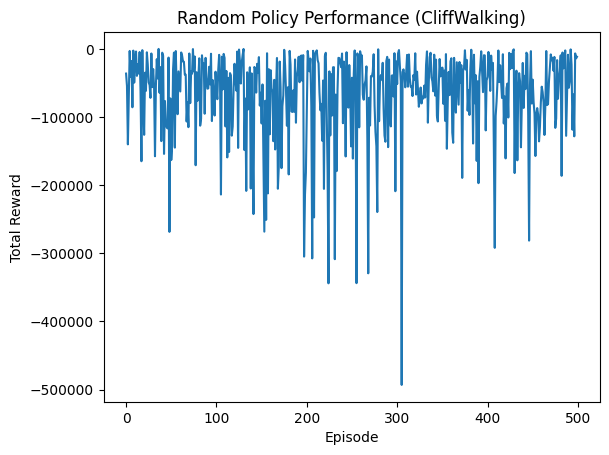

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Create environment
env = gym.make("CliffWalking-v1")

# Helper functions (兼容 gym / gymnasium)
def reset_env(env):
    out = env.reset()
    if isinstance(out, tuple):
        return out[0]
    return out

def step_env(env, action):
    out = env.step(action)
    if len(out) == 5:
        next_state, reward, terminated, truncated, _ = out
        done = terminated or truncated
    else:
        next_state, reward, done, _ = out
    return next_state, reward, done

# Random policy baseline
num_episodes = 500
rewards = []

for episode in range(num_episodes):
    state = reset_env(env)
    done = False
    total_reward = 0

    while not done:
        action = env.action_space.sample()  # 随机动作
        next_state, reward, done = step_env(env, action)

        total_reward += reward
        state = next_state

    rewards.append(total_reward)

# Results
avg_reward = np.mean(rewards)
std_reward = np.std(rewards)

print(f"Average reward (random policy): {avg_reward:.2f}")
print(f"Std of reward: {std_reward:.2f}")

# Plot performance
plt.figure()
plt.plot(rewards)
plt.title("Random Policy Performance (CliffWalking)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

Average training reward: -1813.89
Std of training reward: 8651.72


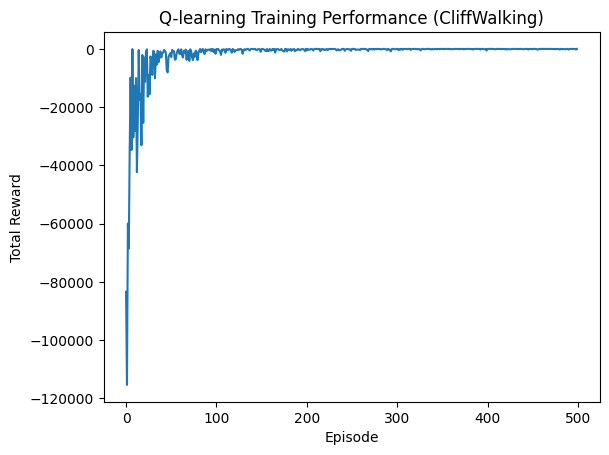

Average evaluation reward (greedy policy): -13.00
Std of evaluation reward: 0.00


In [ ]:
num_states = env.observation_space.n
num_actions = env.action_space.n

# Represent the action-value function as a Q-table
Q_table = np.zeros((num_states, num_actions))

# Hyperparameters
alpha = 0.1
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
num_episodes = 500

train_rewards = []

# Epsilon-greedy policy
def choose_action(state, epsilon):
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    return np.argmax(Q_table[state])

# Training
for episode in range(num_episodes):
    state = reset_env(env)
    done = False
    total_reward = 0

    while not done:
        action = choose_action(state, epsilon)
        next_state, reward, done = step_env(env, action)

        # Q-learning update
        best_next_q = np.max(Q_table[next_state])
        td_target = reward + gamma * best_next_q * (not done)
        Q_table[state, action] += alpha * (td_target - Q_table[state, action])

        total_reward += reward
        state = next_state

    train_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

# Training statistics
print(f"Average training reward: {np.mean(train_rewards):.2f}")
print(f"Std of training reward: {np.std(train_rewards):.2f}")

# Plot training reward
plt.figure()
plt.plot(train_rewards)
plt.title("Q-learning Training Performance (CliffWalking)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

# Separate evaluation using greedy policy (epsilon = 0)
num_eval_episodes = 100
eval_rewards = []

for episode in range(num_eval_episodes):
    state = reset_env(env)
    done = False
    total_reward = 0

    while not done:
        action = np.argmax(Q_table[state])  # greedy policy
        next_state, reward, done = step_env(env, action)

        total_reward += reward
        state = next_state

    eval_rewards.append(total_reward)

print(f"Average evaluation reward (greedy policy): {np.mean(eval_rewards):.2f}")
print(f"Std of evaluation reward: {np.std(eval_rewards):.2f}")

Random baseline avg reward: -66233.67
Decaying epsilon avg reward (last 100 episodes): -49.37
Fixed epsilon avg reward (last 100 episodes): -43.13
Decaying epsilon success rate: 1.00
Fixed epsilon success rate: 1.00


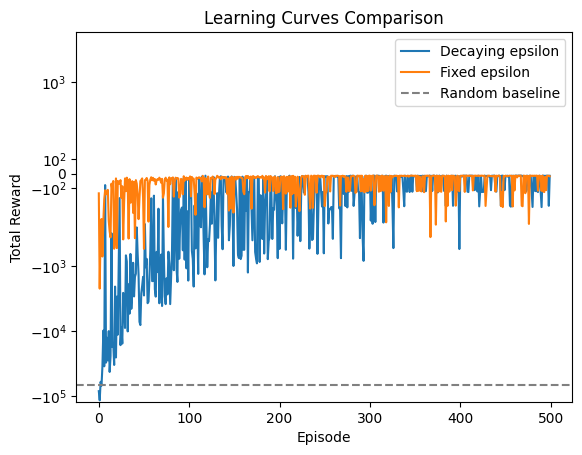

Learned Policy (Decaying Epsilon Q-learning):
→ → ↓ → → → ↓ → → → → ↓
→ → → ↓ → ↓ → → ↓ → → ↓
→ → → → → → → → → → → ↓
↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑


In [ ]:
#Part C

#Q-learning with fixed epsilon
epsilon_fixed = 0.1
Q_fixed = np.zeros((num_states, num_actions))
fixed_rewards = []

for episode in range(num_episodes):
    state = reset_env(env)
    done = False
    total_reward = 0

    while not done:
        #Picks random or best known action
        if np.random.rand() < epsilon_fixed:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q_fixed[state])

        next_state, reward, done = step_env(env, action)

        #Q-learning update
        best_next_q = np.max(Q_fixed[next_state])
        td_target = reward + gamma * best_next_q * (not done)
        Q_fixed[state, action] += alpha * (td_target - Q_fixed[state, action])

        total_reward += reward
        state = next_state

    fixed_rewards.append(total_reward)

#Evaluation of both Q-learning variants
num_eval_episodes = 100
eval_rewards_decaying = []
eval_rewards_fixed = []

for Q_table_variant, eval_rewards in [(Q_table, eval_rewards_decaying), (Q_fixed, eval_rewards_fixed)]:
    for _ in range(num_eval_episodes):
        state = reset_env(env)
        done = False
        total_reward = 0

        while not done:
            action = np.argmax(Q_table_variant[state])  # greedy
            next_state, reward, done = step_env(env, action)
            total_reward += reward
            state = next_state

        eval_rewards.append(total_reward)

#Success rate
success_rate_decaying = sum(r > -100 for r in eval_rewards_decaying) / num_eval_episodes
success_rate_fixed = sum(r > -100 for r in eval_rewards_fixed) / num_eval_episodes

#Quantitative comparison
print(f"Random baseline avg reward: {np.mean(rewards):.2f}")
print(f"Decaying epsilon avg reward (last 100 episodes): {np.mean(train_rewards[-100:]):.2f}")
print(f"Fixed epsilon avg reward (last 100 episodes): {np.mean(fixed_rewards[-100:]):.2f}")
print(f"Decaying epsilon success rate: {success_rate_decaying:.2f}")
print(f"Fixed epsilon success rate: {success_rate_fixed:.2f}")

#Learning curves
plt.figure()
plt.plot(train_rewards, label="Decaying epsilon")
plt.plot(fixed_rewards, label="Fixed epsilon")
plt.axhline(np.mean(rewards), linestyle='--', color='gray', label="Random baseline")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Learning Curves Comparison")
plt.yscale('symlog', linthresh=500)
plt.legend()
plt.show()

#Visualize final learned policy
policy = np.argmax(Q_table, axis=1)
policy_grid = policy.reshape((4, 12))
arrow_map = {0:"↑", 1:"→", 2:"↓", 3:"←"}

print("Learned Policy (Decaying Epsilon Q-learning):")
for row in policy_grid:
    print(" ".join(arrow_map[a] for a in row))

Part D: Interpretation

How Exploration Affected Learning

Exploration played a central role in enabling the agent to learn an effective policy in CliffWalking. Without exploration, the agent would greedily exploit whatever it had learned early on, locking itself into suboptimal paths or never discovering the rewarding route near the cliff edge. With decaying epsilon, the agent starts with high exploration (ε = 1.0), taking random actions and broadly sampling the state space. As training progresses, epsilon decays toward 0.05, allowing the agent to increasingly exploit the Q-values it has accumulated. This schedule lets the agent learn confidently once it has enough experience, and the evaluation results confirm convergence to a near-optimal greedy policy (average reward of −13).

With fixed epsilon (ε = 0.1), the agent maintains a constant 10% chance of random action throughout training. This sustains some exploration even in late episodes, which slightly reduces the quality of learned Q-values compared to a fully greedy policy, but as shown in Part C, both variants achieve similar performance (success rate of 1.00), since the environment is deterministic and not overly large.


Failure Mode: Slow Convergence from High Alpha

A notable failure mode in Q-learning is unstable or oscillating Q-values caused by a learning rate (α) that is too high. If α is set close to 1.0, each new TD update essentially overwrites the previous Q-value estimate rather than gradually refining it. In an environment like CliffWalking, where a single misstep sends the agent off the cliff with a penalty of −100. A high α causes the agent to react too strongly to each reward signal, leading to wild swings in Q-values and preventing stable convergence. The agent may repeatedly "unlearn" good behaviors after experiencing a cliff-fall episode, resulting in erratic learning curves and slow overall convergence.



Interaction of α, γ, and ε in This Environment

- α (learning rate = 0.1): Controls how much each new experience updates the Q-value. A small α means the agent learns slowly but stably, averaging out noise over many episodes. In CliffWalking, this is appropriate because the penalty structure is harsh and stochastic early behavior can send misleading gradient signals.

- γ (discount factor = 0.99): Controls how much the agent values future rewards. A high γ like 0.99 makes the agent nearly as concerned with future rewards as immediate ones, which is critical in CliffWalking. The goal is far away and requires many steps; if γ were low (e.g., 0.5), the agent would prioritize short-term rewards and might not learn to reach the goal at all.

- ε (exploration rate): Governs the explore-exploit tradeoff. In CliffWalking, early high exploration (ε = 1.0) ensures the agent discovers the cliff, the goal, and safe paths. As ε decays, the agent can commit to the best-known policy. The interplay between ε and α matters: high ε generates more diverse training data, which — combined with a moderate α — allows the Q-table to converge to accurate values without overfitting to any single trajectory.

Together, these hyperparameters create a stable learning dynamic: γ keeps the agent goal-oriented, α prevents overreaction to individual experiences, and ε ensures broad state-space coverage early in training.